### distributions

-----------------

In this notebook, we apply the suppression effects to a complete n(z) in order to recover the full distribution, with both gaussian processes and with a shifted-stretched model (SSM)

In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import json
from astropy.io import fits

from pathlib import Path
from scipy.integrate import simpson

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf

# specific implementations for modelling 
import src.statistics.sgp as sgp # around gaussian processes

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [3]:
stem = 'v14'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})
assert all([p.exists() for p in path_dictionary.values()])

In [21]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
tomobin = 4
tracer = 'Merged'
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    do_bias_correction=False,
    scale_cuts=[.3, 2.5],
    tracer=tracer,
    tomo_bin=tomobin,
    rebin=1
)
zbins = inference._get_fine_redshift_bins(
    fr=cf.CorrFileReader(path_dictionary['DESI_NGC']),
    tracer=tracer
)
zvals = (zbins[:-1] + zbins[1:]) / 2

Using merged method for tracer Merged and tomo bin 4.


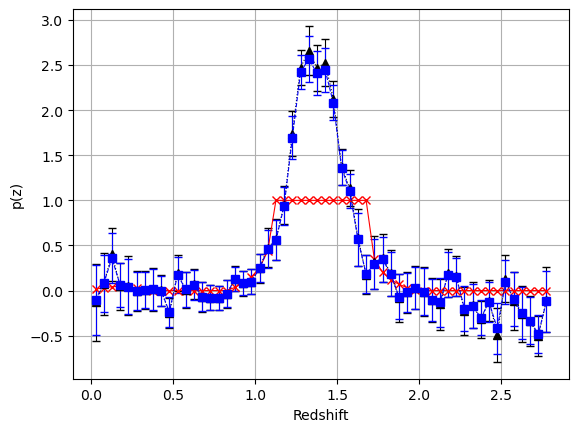

In [22]:
importlib.reload(sgp)
plt.errorbar(zvals, meas[0], meas[1], capsize=3, color='black', marker='^', linestyle=':', linewidth=0.8)
gp = sgp.gpfit(zvals, meas)
suppression_kernel = sgp.suppression(zvals, gp[0], gp[1])
plt.errorbar(zvals, gp[0], gp[1], capsize=3, color='blue', marker='s', linestyle='--', linewidth=0.8)
plt.plot(zvals, suppression_kernel, color='red', marker='x', linestyle='-', linewidth=0.8, label='Suppression kernel')
plt.xlabel('Redshift')
plt.ylabel('p(z)')
plt.grid(True)

ValueError: operands could not be broadcast together with shapes (20,500) (42,1) 

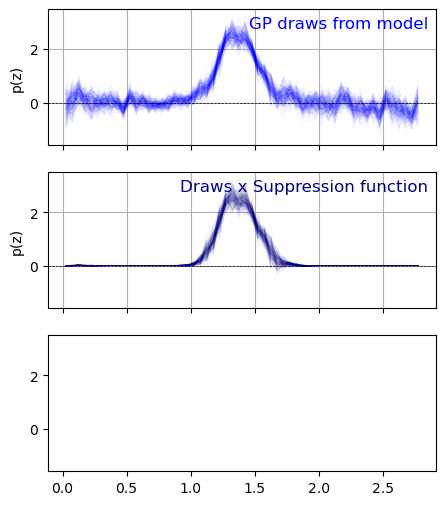

In [23]:
importlib.reload(sgp)

draws = sgp.draw_from_gp(gp[0], gp[1], seed=123, n_draws=200)
suppressed_draws = draws * suppression_kernel[:, np.newaxis]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 1.5*4), sharex=True, sharey=True)

# gp draws
ax1.plot(zvals, draws, color='blue', alpha=0.05, linewidth=0.5)
ax1.grid()
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax1.text(0.98, 0.95, 'GP draws from model', color='blue', fontsize=12, ha='right', va='top', transform=ax1.transAxes)
ax1.set_ylabel('p(z)')

# suppressed draws
ax2.plot(zvals, suppressed_draws, color='darkblue', alpha=0.05, linewidth=0.5)
ax2.grid()
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.text(0.98, 0.95, 'Draws x Suppression function', color='darkblue', fontsize=12, ha='right', va='top', transform=ax2.transAxes)
ax2.set_ylabel('p(z)')

# 1σ envelope + median + renormalized suppressed draws
mask = (zvals > 1) & (zvals < 2)
mean, err = sgp.suppress_nz(zvals[mask], gp[0][mask], gp[1][mask])
ax3.fill_between(zvals, mean-err, mean+err, color='purple', alpha=0.3, step='mid')
ax3.plot(zvals, mean, color='black', linewidth=1.2, drawstyle='steps-mid')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax3.grid()
ax3.text(0.98, 0.95, 'Suppressed GP Model', color='purple', fontsize=12, ha='right', va='top', transform=ax3.transAxes)
ax3.set_ylabel('p(z)')

plt.xlabel('Redshift')
plt.tight_layout()
plt.show()


In [ ]:
w = comb.trapz_weights(zvals)
mask = (zvals > 1) & (zvals < 2)
mean_nz = np.trapz(mean[mask] * zvals[mask], x=zvals[mask])
mean_nz_err = np.sqrt(np.sum(err**2 * w**2))
print(f'Mean p(z) = {mean_nz:.3f} ± {mean_nz_err:.3f}')

Mean p(z) = 0.434 ± 0.046


Using merged method for tracer Merged and tomo bin 1.
0 negative values in mean
Area under nz_1 : 0.791
First moment : 0.450
Using merged method for tracer Merged and tomo bin 2.
0 negative values in mean
Area under nz_2 : 0.714
First moment : 0.767
Using merged method for tracer Merged and tomo bin 3.
0 negative values in mean
Area under nz_3 : 0.791
First moment : 1.082
Using merged method for tracer Merged and tomo bin 4.
0 negative values in mean
Area under nz_4 : 0.938
First moment : 1.375
FITS file saved to: nz.fits


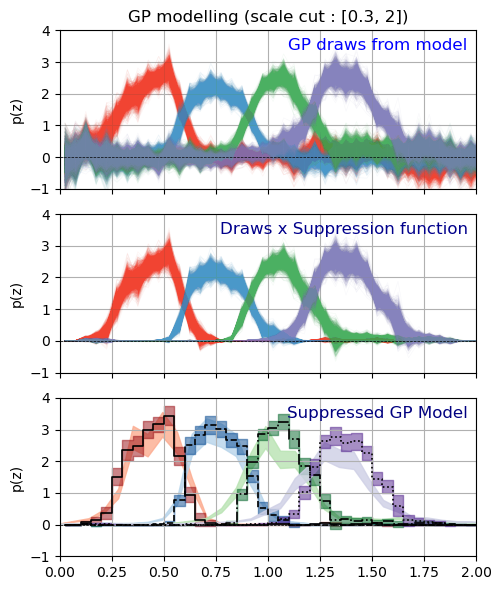

In [159]:
importlib.reload(sgp)
tracer = 'Merged'
zbins = inference._get_fine_redshift_bins(
        fr=cf.CorrFileReader(path_dictionary['DESI_NGC']),
        tracer=tracer
    )
zvals = (zbins[:-1] + zbins[1:]) / 2
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 6), sharex=True, sharey=True)
scale_cut = [.3, 2]

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')
mids = tomo_bin_dnnz[:, 0]

# Prepare FITS table data
# Calculate bin edges from midpoints
dz = np.mean(np.diff(zvals))
z_low = zvals - dz/2
z_high = zvals + dz/2
z_mid = zvals

fits_data = {
    'Z_LOW': z_low,
    'Z_MID': z_mid,
    'Z_HIGH': z_high
}

for tb in [1,2,3,4]:
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=False,
        scale_cuts=scale_cut,
        tracer=tracer,
        tomo_bin=tb,
        rebin=1
    )

    gp = sgp.gpfit(zvals, meas)
    suppression_kernel = sgp.suppression(zvals, gp[0], gp[1], damping=0.6)

    draws = sgp.draw_from_gp(gp[0], gp[1], seed=123, n_draws=2000)
    suppressed_draws = draws * suppression_kernel[:, np.newaxis]

    # gp draws
    ax1.plot(zvals, draws, color=colormaps[tb-1](0.6), alpha=0.05, linewidth=0.5)

    # suppressed draws
    ax2.plot(zvals, suppressed_draws, color=colormaps[tb-1](0.6), alpha=0.05, linewidth=0.5)

    # 1σ envelope + mean
    mean, lower, upper = sgp.get_enveloppe(suppressed_draws, sigma_level=1)
    # ensure non-negative values
    mean = np.maximum(mean, 0)
    print(np.sum(mean < 0), 'negative values in mean')
     
    # renormalize to 1
    area = np.trapz(mean, zvals)
    mean /= area
    lower /= area
    upper /= area
    print(f'Area under nz_{tb} : {area:.3f}')
    print(f'First moment : {np.trapz(mean * zvals, zvals):.3f}')

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tb], mids)

    ax3.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[tb-1](0.3), 
        alpha=0.8
        )

    ax3.fill_between(zvals, lower, upper, color=colormaps[tb-1](0.9), alpha=0.5, step='mid')
    ax3.plot(zvals, mean, color='black', linewidth=1.2, drawstyle='steps-mid', linestyle=linestyles[tb-1])

    # Store data for FITS file
    fits_data[f'BIN_{tb}'] = mean
    #assert np.all(mean >= 0), f'Non-finite values in BIN_{tb}'
    fits_data[f'BIN_{tb}_ERR'] = (upper - lower) / 2

ax1.set_title(f'GP modelling (scale cut : {scale_cut})')
ax1.grid()
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax1.text(0.98, 0.95, 'GP draws from model', color='blue', fontsize=12, ha='right', va='top', transform=ax1.transAxes)
ax1.set_ylabel('p(z)')
ax1.set_xlim(0, 2)
ax2.set_ylim(-1, 4)

ax2.grid()
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.text(0.98, 0.95, 'Draws x Suppression function', color='darkblue', fontsize=12, ha='right', va='top', transform=ax2.transAxes)
ax2.set_ylabel('p(z)')
ax2.set_xlim(0, 2)
ax2.set_ylim(-1, 4)

ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax3.grid()
ax3.text(0.98, 0.95, 'Suppressed GP Model', color='navy', fontsize=12, ha='right', va='top', transform=ax3.transAxes)
ax3.set_ylabel('p(z)')
ax3.set_xlim(0, 2)
ax3.set_ylim(-1, 4)

# Create FITS table with proper column ordering
column_order = ['Z_LOW', 'Z_MID', 'Z_HIGH'] + [f'BIN_{i}' for i in [1,2,3,4]] + [f'BIN_{i}_ERR' for i in [1,2,3,4]]
columns = []

for col_name in column_order:
    columns.append(fits.Column(name=col_name, format='E', array=fits_data[col_name]))

# Create binary table HDU
table_hdu = fits.BinTableHDU.from_columns(columns)

# Add metadata to header
table_hdu.header['TRACER'] = tracer
table_hdu.header['SCALECUT'] = json.dumps(scale_cut)
table_hdu.header['COMMENT'] = 'Redshift distribution with tomographic bins'
table_hdu.header['COMMENT'] = 'Z_LOW, Z_MID, Z_HIGH: redshift bin boundaries and centers'
table_hdu.header['COMMENT'] = 'BIN_i: normalized n(z) for tomographic bin i'
table_hdu.header['COMMENT'] = 'BIN_i_ERR: 1-sigma uncertainty on BIN_i'

# Create primary HDU and HDU list
primary_hdu = fits.PrimaryHDU()
primary_hdu.header['TRACER'] = tracer
primary_hdu.header['SCALECUT'] = json.dumps(scale_cut)
primary_hdu.header['COMMENT'] = 'Redshift distributions from Gaussian Process modeling, v14 (DR2)'

hdul = fits.HDUList([primary_hdu, table_hdu])

# Write FITS file
outpath = 'nz.fits'
hdul.writeto(outpath, overwrite=True)
print(f'FITS file saved to: {outpath}')

plt.tight_layout()
plt.show()

In [156]:
from astropy.table import Table
tbl = Table.read('nz.fits')
print(tbl['BIN_1'])
print(tbl['BIN_2'])
print(tbl['BIN_3'])
print(tbl['BIN_4'])

   BIN_1    
------------
         0.0
0.0008874261
 0.041747767
  0.08060909
  0.21222833
   1.2768531
   2.4465928
   2.5831563
    3.097884
   3.2430098
         ...
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
Length = 56 rows
    BIN_2    
-------------
          0.0
          0.0
  0.013530406
 -0.005650639
-0.0009001103
          0.0
          0.0
          0.0
          0.0
 0.0050564213
          ...
          0.0
          0.0
          0.0
-0.0018227454
          0.0
          0.0
          0.0
          0.0
          0.0
          0.0
Length = 56 rows
    BIN_3     
--------------
           0.0
           0.0
   0.016945753
 -0.0043567186
  -0.001395638
           0.0
           0.0
           0.0
           0.0
           0.0
           ...
           0.0
           0.0
-0.00013336267
  9.754566e-05
           0.0
           0.0
           0.0
           0.0
           0.0
           0.0
